In [ ]:
!pip install seaborn --quiet

# ── Data handling ─────────────────────────────────────────────
import pandas as pd           # handles spreadsheet-like data (tables)
import numpy as np            # math on numbers and arrays

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt  # draws graphs and charts
import seaborn as sns          # makes prettier graphs on top of matplotlib

# ── Machine Learning (scikit-learn) ───────────────────────────
from sklearn.linear_model import LinearRegression   # prediction model
from sklearn.cluster import KMeans                # grouping algorithm
from sklearn.model_selection import train_test_split # split into train/test
from sklearn.preprocessing import StandardScaler   # normalize values
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Utility ───────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # hide non-critical warning messages

# Style settings for all graphs in this notebook
plt.style.use('seaborn-v0_8-whitegrid')   # clean white background with grid
sns.set_palette('husl')                    # set default color palette

print("✅ All libraries imported successfully! Ready to code.")

✅ All libraries imported successfully! Ready to code.


In [ ]:
from google.colab import files

print("A file picker will open. Select BOTH .csv files.")
uploaded = files.upload()  # opens a file picker dialog

print("\n✅ Files uploaded:", list(uploaded.keys()))

A file picker will open. Select BOTH .csv files.


Saving dengue_features_train.csv to dengue_features_train.csv
Saving dengue_labels_train.csv to dengue_labels_train.csv

✅ Files uploaded: ['dengue_features_train.csv', 'dengue_labels_train.csv']


In [ ]:
#  Load both CSV files into DataFrames
# pd.read_csv reads a CSV file into a table we can work with
features = pd.read_csv('dengue_features_train.csv')
labels   = pd.read_csv('dengue_labels_train.csv')

# Merge them into one table by adding total_cases as a new column
df = features.copy()
df['total_cases'] = labels['total_cases']

# Basic info
print(f"✅ Dataset loaded! Shape: {df.shape}")  # (rows, columns)
print(f"   Cities: {df['city'].unique()}")
print(f"   Years: {df['year'].min()} to {df['year'].max()}")

✅ Dataset loaded! Shape: (1456, 25)
   Cities: ['sj' 'iq']
   Years: 1990 to 2010


In [ ]:
# ── STEP 3: Data Exploration ──────────────────────────────────

# 1. Show first 5 rows (like a preview of the spreadsheet)
print("=== First 5 rows of the dataset ===")
print(df.head())

# 2. Basic statistics (average, min, max for each column)
print("\n=== Basic Statistics ===")
print(df[['total_cases', 'reanalysis_air_temp_k',
         'precipitation_amt_mm', 'reanalysis_relative_humidity_percent'
       ]].describe().round(2))

# 3. Count missing values per column
print("\n=== Missing Values (columns with gaps) ===")
missing = df.isnull().sum()
print(missing[missing > 0])   # only show columns that HAVE missing values

# 4. How many weeks per city?
print("\n=== Rows per City ===")
print(df['city'].value_counts())

=== First 5 rows of the dataset ===
  city  year  weekofyear week_start_date   ndvi_ne   ndvi_nw   ndvi_se  \
0   sj  1990          18      1990-04-30  0.122600  0.103725  0.198483   
1   sj  1990          19      1990-05-07  0.169900  0.142175  0.162357   
2   sj  1990          20      1990-05-14  0.032250  0.172967  0.157200   
3   sj  1990          21      1990-05-21  0.128633  0.245067  0.227557   
4   sj  1990          22      1990-05-28  0.196200  0.262200  0.251200   

    ndvi_sw  precipitation_amt_mm  reanalysis_air_temp_k  ...  \
0  0.177617                 12.42             297.572857  ...   
1  0.155486                 22.82             298.211429  ...   
2  0.170843                 34.54             298.781429  ...   
3  0.235886                 15.36             298.987143  ...   
4  0.247340                  7.52             299.518571  ...   

   reanalysis_relative_humidity_percent  reanalysis_sat_precip_amt_mm  \
0                             73.365714                

In [ ]:
# ── STEP 4: Data Cleaning ─────────────────────────────────────

print(f"Missing values BEFORE: {df.isnull().sum().sum()}")

# ── Fix 1: Forward fill missing values ────────────────────────
# Forward fill = use the value from the PREVIOUS row to fill the gap
# Example: if week 10 temp is missing, use week 9's temp
df = df.ffill()   # fills going forward (down the column)
df = df.bfill()   # fills backward (handles any missing at the very start)

print(f"Missing values AFTER:  {df.isnull().sum().sum()}")
# Should print 0

# ── Fix 2: Convert date column from text to real date ──────────
# Currently "1990-04-30" is just text. pd.to_datetime makes it a real date.
df['week_start_date'] = pd.to_datetime(df['week_start_date'])

# ── Fix 3: Extract useful numbers from the date ───────────────
df['month'] = df['week_start_date'].dt.month   # 1 = January, 12 = December
df['week']  = df['week_start_date'].dt.isocalendar().week.astype(int)

# ── Fix 4: Work with San Juan city only (simpler to start) ────
sj = df[df['city'] == 'sj'].reset_index(drop=True)

print(f"\n✅ Cleaning complete!")
print(f"   Working with: San Juan data = {len(sj)} weeks")
print(f"   Date range: {sj['week_start_date'].min().date()} → {sj['week_start_date'].max().date()}")

Missing values BEFORE: 548
Missing values AFTER:  0

✅ Cleaning complete!
   Working with: San Juan data = 936 weeks
   Date range: 1990-04-30 → 2008-04-22


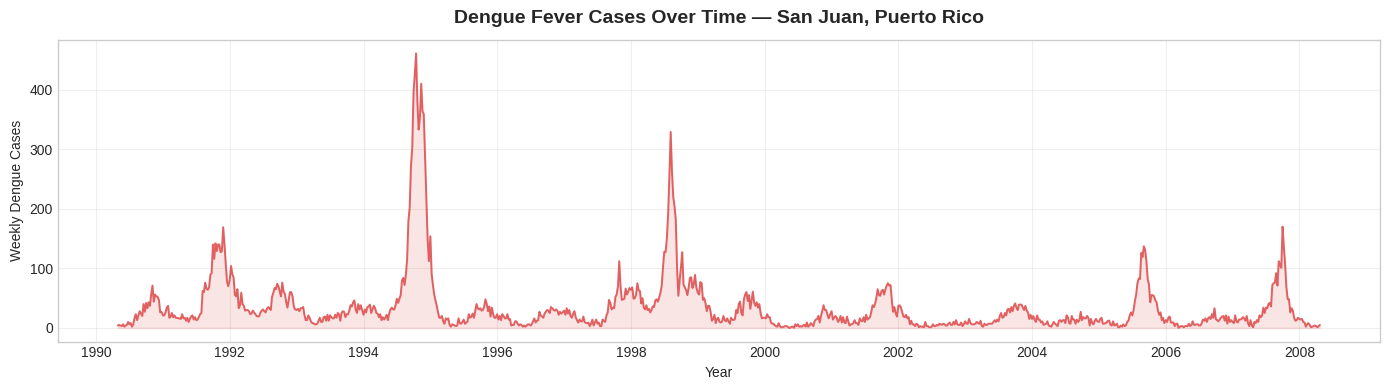

✅ Graph 1 saved as graph1_time_series.png


In [ ]:
# ── GRAPH 1: Disease cases over time (time series) ────────────

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(sj['week_start_date'], sj['total_cases'],
       color='#e05252', linewidth=1.4, alpha=0.9)

# Fill the area under the line for visual effect
ax.fill_between(sj['week_start_date'], sj['total_cases'],
               alpha=0.15, color='#e05252')

ax.set_title('Dengue Fever Cases Over Time — San Juan, Puerto Rico',
            fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Weekly Dengue Cases')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 1 saved as graph1_time_series.png")

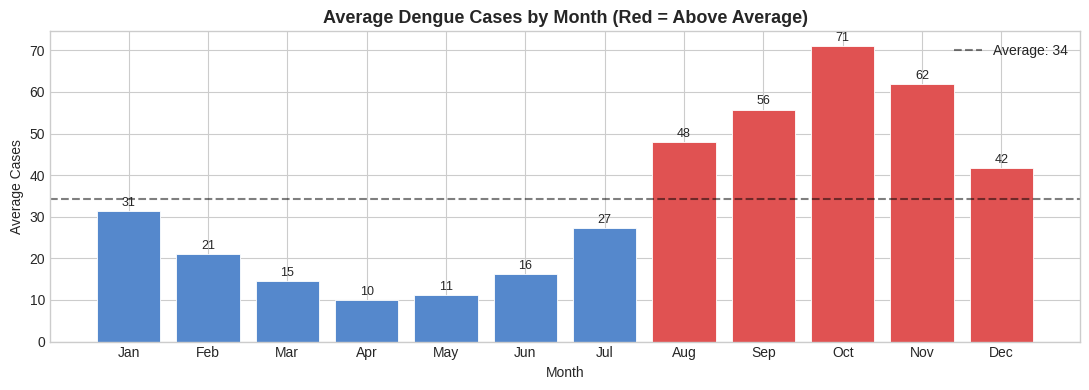

✅ Graph 2 saved


In [ ]:
# ── GRAPH 2: Average cases by month (seasonality) ─────────────

# Group by month and calculate average cases per month
monthly = sj.groupby('month')['total_cases'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Color bars red if above average, blue if below average
avg = monthly.mean()
bar_colors = ['#e05252' if v > avg else '#5588cc' for v in monthly]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(month_names, monthly.values, color=bar_colors,
              edgecolor='white', linewidth=0.6)

# Add value labels on top of each bar
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
           f'{val:.0f}', ha='center', va='bottom', fontsize=9)

ax.axhline(avg, color='black', linestyle='--', alpha=0.5, label=f'Average: {avg:.0f}')
ax.set_title('Average Dengue Cases by Month (Red = Above Average)',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Cases')
ax.legend()
plt.tight_layout()
plt.savefig('graph2_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 2 saved")

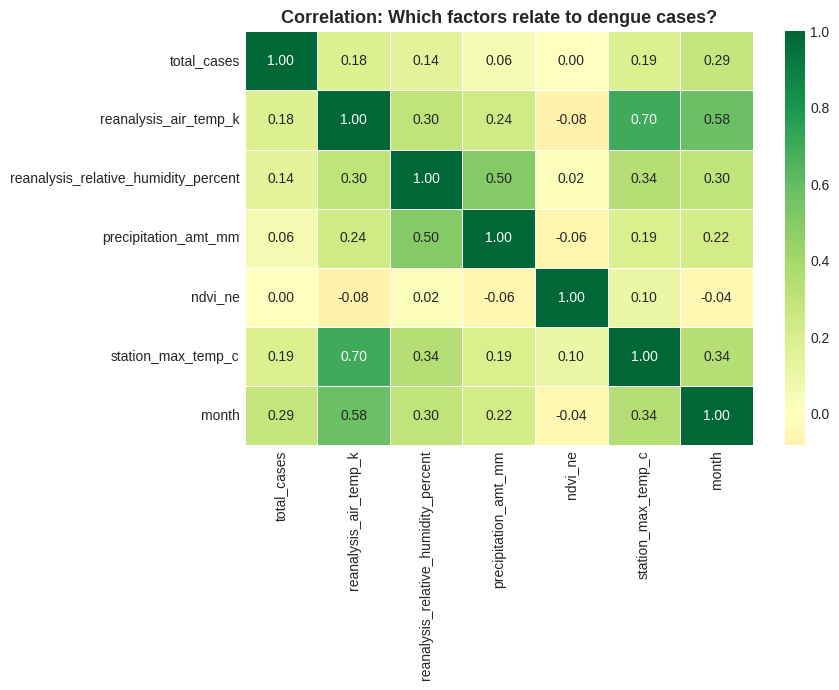

✅ Graph 3 saved


In [ ]:
# ── GRAPH 3: Correlation Heatmap ─────────────────────────────
# Shows which environmental factors are most related to dengue cases

# Select only numerical columns for correlation
num_cols = ['total_cases', 'reanalysis_air_temp_k',
            'reanalysis_relative_humidity_percent', 'precipitation_amt_mm',
            'ndvi_ne', 'station_max_temp_c', 'month']

corr_matrix = sj[num_cols].corr()  # calculate correlation (-1 to 1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix,
           annot=True,       # show numbers inside each box
           fmt='.2f',         # 2 decimal places
           cmap='RdYlGn',    # Red (negative) to Green (positive)
           center=0,          # white = zero correlation
           linewidths=0.5,
           ax=ax)
ax.set_title('Correlation: Which factors relate to dengue cases?',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 3 saved")

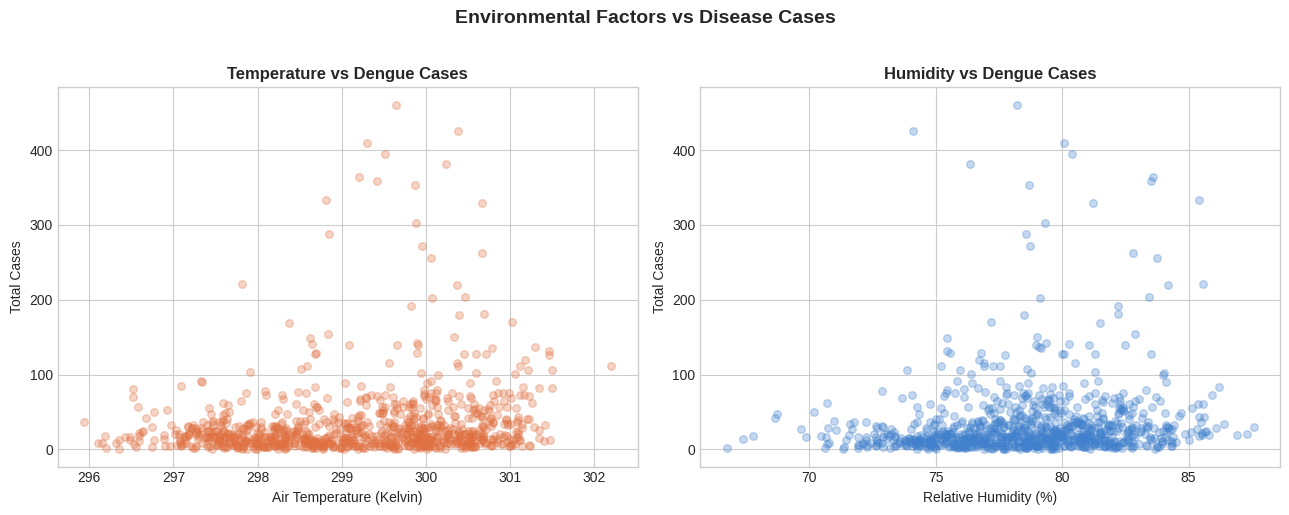

✅ Graph 4 saved


In [ ]:
# ── GRAPH 4: Scatter plot — Temperature vs Dengue Cases ───────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Temperature vs Cases
axes[0].scatter(sj['reanalysis_air_temp_k'], sj['total_cases'],
               alpha=0.3, color='#e07040', s=30)
axes[0].set_title('Temperature vs Dengue Cases', fontweight='bold')
axes[0].set_xlabel('Air Temperature (Kelvin)')
axes[0].set_ylabel('Total Cases')

# Right: Humidity vs Cases
axes[1].scatter(sj['reanalysis_relative_humidity_percent'],
               sj['total_cases'],
               alpha=0.3, color='#4080cc', s=30)
axes[1].set_title('Humidity vs Dengue Cases', fontweight='bold')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('Total Cases')

plt.suptitle('Environmental Factors vs Disease Cases',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 4 saved")

In [ ]:
# ── STEP 6a: Choose features (inputs) and target (output) ─────

# INPUT FEATURES — environmental factors we give the model
features = [
    'reanalysis_air_temp_k',                 # temperature
    'reanalysis_relative_humidity_percent',   # humidity
    'precipitation_amt_mm',                   # rainfall
    'ndvi_ne',                                # vegetation zone NE
    'ndvi_sw',                                # vegetation zone SW
    'station_max_temp_c',                     # max temperature
    'station_min_temp_c',                     # min temperature
    'month',                                  # month of year (captures seasons)
    'week'                                    # week number
]

X = sj[features]         # input matrix (all 9 environmental features)
y = sj['total_cases']   # output — what we want to predict

# ── STEP 6b: Split data into training set and testing set ─────
# Training: the model LEARNS from this (80% of data)
# Testing:  we TEST how good it is on data it has NEVER seen (20%)
# shuffle=False keeps time order (very important for time-series data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # fixed seed so you get same split every time
    shuffle=False       # keep time order — NEVER shuffle time-series data
)

print(f"Training set: {len(X_train)} weeks → model learns from these")
print(f"Testing set:  {len(X_test)} weeks → we test model on these")

Training set: 748 weeks → model learns from these
Testing set:  188 weeks → we test model on these


In [ ]:
# ── STEP 6c: Scale the features ───────────────────────────────
# Why scale? Temperature is ~300 (Kelvin), humidity is ~70 (percent)
# Without scaling, the model thinks temperature is more important
# just because it's a bigger number. Scaling fixes this.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # learn scale FROM training data
X_test_sc  = scaler.transform(X_test)        # apply SAME scale to test data
# IMPORTANT: never fit_transform on test data!

# ── STEP 6d: Create and train the Linear Regression model ─────
model = LinearRegression()         # create a blank model
model.fit(X_train_sc, y_train)    # train it — "fit" = learn the pattern

print("✅ Model trained!")
print("\nFeature importance (+ means more cases, - means fewer):")
for feat, coef in sorted(zip(features, model.coef_),
                            key=lambda x: abs(x[1]), reverse=True):
    arrow = "↑" if coef > 0 else "↓"
    print(f"  {arrow} {feat:45s} {coef:+.2f}")

✅ Model trained!

Feature importance (+ means more cases, - means fewer):
  ↑ week                                          +12.50
  ↑ station_max_temp_c                            +8.75
  ↓ reanalysis_air_temp_k                         -8.21
  ↑ month                                         +5.69
  ↑ ndvi_sw                                       +3.88
  ↑ reanalysis_relative_humidity_percent          +3.76
  ↓ precipitation_amt_mm                          -2.79
  ↓ ndvi_ne                                       -2.39
  ↓ station_min_temp_c                            -1.58


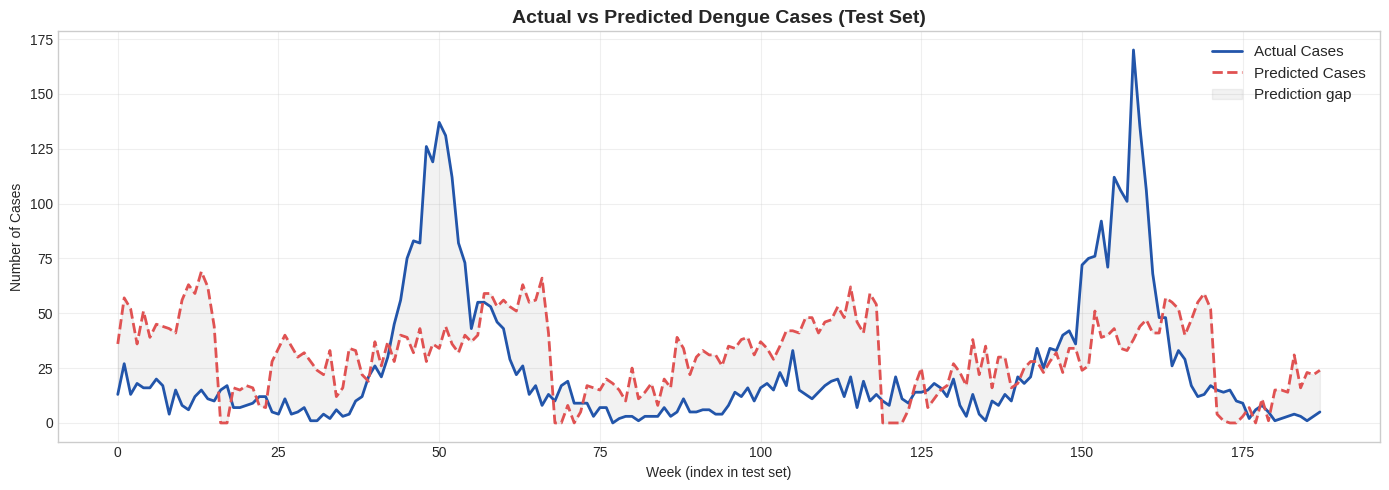


── Hypothetical Next-Week Prediction ──
Input: Temp=302K, Humidity=82%, Rainfall=55mm, Month=August
Predicted dengue cases next week: 29


In [ ]:
# ── STEP 7: Make predictions on test data ─────────────────────

y_pred = model.predict(X_test_sc)  # model predicts values
# Clean up: no negative values, round to whole number
y_pred_clean = np.maximum(np.round(y_pred).astype(int), 0)

# ── Graph 5: Actual vs Predicted ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x_axis = range(len(y_test))

ax.plot(x_axis, y_test.values, label='Actual Cases',
       color='#2255aa', linewidth=2)
ax.plot(x_axis, y_pred_clean, label='Predicted Cases',
       color='#e05252', linewidth=2, linestyle='--')
ax.fill_between(x_axis, y_test.values, y_pred_clean,
               alpha=0.1, color='gray', label='Prediction gap')

ax.set_title('Actual vs Predicted Dengue Cases (Test Set)',
            fontsize=14, fontweight='bold')
ax.set_xlabel('Week (index in test set)')
ax.set_ylabel('Number of Cases')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph5_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Predict a hypothetical next week ──────────────────────────
print("\n── Hypothetical Next-Week Prediction ──")
next_week_data = pd.DataFrame([{
    'reanalysis_air_temp_k': 302,
    'reanalysis_relative_humidity_percent': 82,
    'precipitation_amt_mm': 55,
    'ndvi_ne': 0.15, 'ndvi_sw': 0.18,
    'station_max_temp_c': 33, 'station_min_temp_c': 25,
    'month': 8, 'week': 32
}])
next_scaled  = scaler.transform(next_week_data)
prediction   = max(0, int(model.predict(next_scaled)[0]))
print(f"Input: Temp=302K, Humidity=82%, Rainfall=55mm, Month=August")
print(f"Predicted dengue cases next week: {prediction}")

Average dengue cases per cluster:
          Avg Cases
cluster            
0         20.642276
1         32.130755
2        288.708333

Risk level distribution:
risk_level
Medium Risk    543
Low Risk       369
High Risk       24
Name: count, dtype: int64


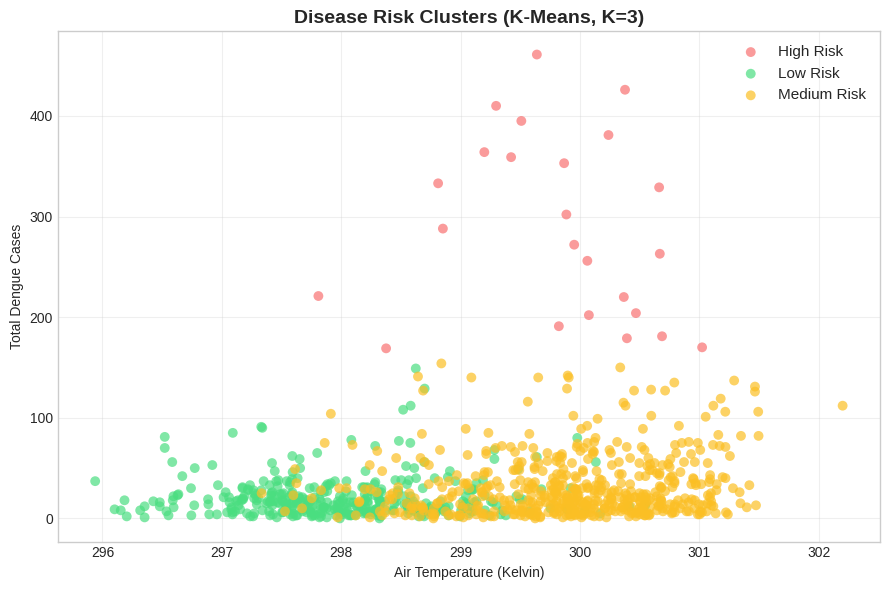

✅ Clustering complete!


In [ ]:
# ── STEP 8: K-Means Clustering ────────────────────────────────

# Features used for clustering (conditions + outcome)
cluster_cols = ['total_cases', 'reanalysis_air_temp_k',
               'reanalysis_relative_humidity_percent',
               'precipitation_amt_mm']

cluster_data = sj[cluster_cols].copy()

# Scale it (same reason as before)
sc2 = StandardScaler()
cluster_scaled = sc2.fit_transform(cluster_data)

# Create K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sj = sj.copy()
sj['cluster'] = kmeans.fit_predict(cluster_scaled)

# Assign Low/Medium/High labels based on average cases per cluster
avg_per_cluster = sj.groupby('cluster')['total_cases'].mean().sort_values()
risk_map = {
    avg_per_cluster.index[0]: 'Low Risk',
    avg_per_cluster.index[1]: 'Medium Risk',
    avg_per_cluster.index[2]: 'High Risk'
}
sj['risk_level'] = sj['cluster'].map(risk_map)

print("Average dengue cases per cluster:")
print(avg_per_cluster.to_frame().rename(columns={'total_cases': 'Avg Cases'}))
print("\nRisk level distribution:")
print(sj['risk_level'].value_counts())

# ── Graph 6: Cluster scatter plot ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'Low Risk': '#4ade80', 'Medium Risk': '#fbbf24', 'High Risk': '#f87171'}

for risk, group in sj.groupby('risk_level'):
    ax.scatter(group['reanalysis_air_temp_k'], group['total_cases'],
              c=colors[risk], label=risk, alpha=0.7, s=50, edgecolors='none')

ax.set_title('Disease Risk Clusters (K-Means, K=3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Air Temperature (Kelvin)')
ax.set_ylabel('Total Dengue Cases')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('graph6_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Clustering complete!")

       MODEL EVALUATION RESULTS
MAE  (Mean Absolute Error)  : 24.73 cases
RMSE (Root Mean Sq Error)   : 32.13 cases
R²   (R-Squared Score)      : -0.0624

Simple Meaning:
  → Predictions are off by ~25 cases on average (MAE)
  → Model explains -6.2% of patterns in data (R²)


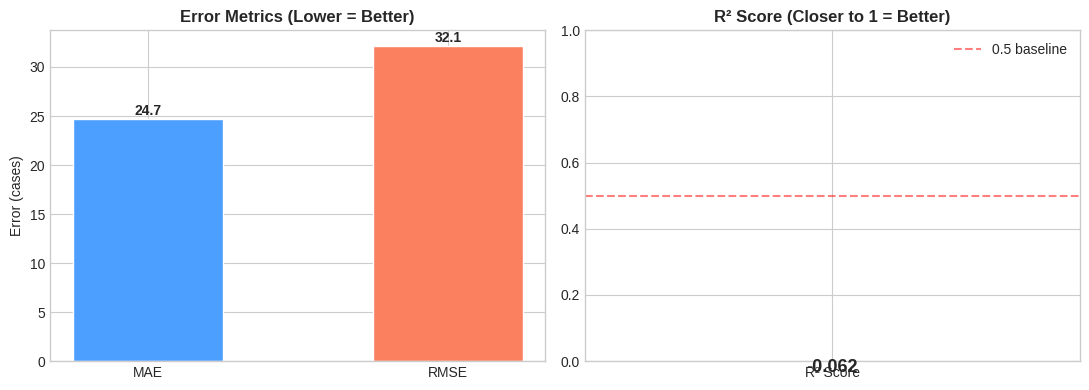

In [ ]:
# ── STEP 9: Calculate evaluation metrics ──────────────────────

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MAE  (Mean Absolute Error)  : {mae:.2f} cases")
print(f"RMSE (Root Mean Sq Error)   : {rmse:.2f} cases")
print(f"R²   (R-Squared Score)      : {r2:.4f}")
print("=" * 50)
print(f"\nSimple Meaning:")
print(f"  → Predictions are off by ~{mae:.0f} cases on average (MAE)")
print(f"  → Model explains {r2*100:.1f}% of patterns in data (R²)")

# ── Graph 7: Evaluation bar chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['MAE', 'RMSE'], [mae, rmse],
           color=['#4d9fff', '#fb8060'], edgecolor='white', width=0.5)
axes[0].set_title('Error Metrics (Lower = Better)', fontweight='bold')
axes[0].set_ylabel('Error (cases)')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 0.4,
               f'{bar.get_height():.1f}', ha='center', fontweight='bold')

axes[1].bar(['R² Score'], [r2], color='#4ade80', edgecolor='white', width=0.4)
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 baseline')
axes[1].set_title('R² Score (Closer to 1 = Better)', fontweight='bold')
axes[1].legend()
axes[1].text(0, r2 + 0.03, f'{r2:.3f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('graph7_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── STEP 10: Project Summary ──────────────────────────────────

print("=" * 60)
print("  ML FOR DISEASE PREVENTION — PROJECT SUMMARY")
print("=" * 60)
print(f"\n📁 DATASET")
print(f"   Source   : DengAI (Kaggle) — Dengue Fever, San Juan")
print(f"   Rows     : {len(sj)} weeks of data")
print(f"   Years    : {sj['year'].min()} to {sj['year'].max()}")
print(f"   Features : {len(features)}")

print(f"\n🤖 ML METHODS USED")
print(f"   1. Linear Regression   → Predict weekly case count")
print(f"   2. K-Means Clustering  → Classify into risk levels")
print(f"   3. Time-series         → Seasonal trend analysis")

print(f"\n📊 MODEL PERFORMANCE")
print(f"   MAE  = {mae:.2f} cases avg error")
print(f"   RMSE = {rmse:.2f} cases")
print(f"   R²   = {r2:.4f}")

print(f"\n🔴 RISK LEVEL DISTRIBUTION")
for risk, count in sj['risk_level'].value_counts().items():
    pct = count / len(sj) * 100
    print(f"   {risk:15s}: {count:4d} weeks ({pct:.1f}%)")

print(f"\n📈 GRAPHS PRODUCED")
for i, g in enumerate([
    "Cases over time", "Monthly seasonality", "Correlation heatmap",
    "Temperature/Humidity scatter", "Actual vs Predicted",
    "Risk clusters", "Evaluation metrics"
], 1):
    print(f"   Graph {i}: {g}")

print(f"\n✅ PROJECT COMPLETE! All graphs saved as PNG files.")
print(f"   Download from: Files panel (📁) on the left side of Colab")
print("=" * 60)

  ML FOR DISEASE PREVENTION — PROJECT SUMMARY

📁 DATASET
   Source   : DengAI (Kaggle) — Dengue Fever, San Juan
   Rows     : 936 weeks of data
   Years    : 1990 to 2008
   Features : 9

🤖 ML METHODS USED
   1. Linear Regression   → Predict weekly case count
   2. K-Means Clustering  → Classify into risk levels
   3. Time-series         → Seasonal trend analysis

📊 MODEL PERFORMANCE
   MAE  = 24.73 cases avg error
   RMSE = 32.13 cases
   R²   = -0.0624

🔴 RISK LEVEL DISTRIBUTION
   Medium Risk    :  543 weeks (58.0%)
   Low Risk       :  369 weeks (39.4%)
   High Risk      :   24 weeks (2.6%)

📈 GRAPHS PRODUCED
   Graph 1: Cases over time
   Graph 2: Monthly seasonality
   Graph 3: Correlation heatmap
   Graph 4: Temperature/Humidity scatter
   Graph 5: Actual vs Predicted
   Graph 6: Risk clusters
   Graph 7: Evaluation metrics

✅ PROJECT COMPLETE! All graphs saved as PNG files.
   Download from: Files panel (📁) on the left side of Colab
